In [1]:
from arcs.generate import GraphGenerator
from arcs.traversal import TableTraversal 
from importlib import resources
import copy 
import numpy as np 
import pandas as pd 
from collections import defaultdict
import matplotlib.pyplot as plt 
import seaborn as sns 
from tqdm.auto import tqdm
from chempy.equilibria import Equilibrium, EqSystem
from chempy import Substance
import itertools as it 
import warnings 
from itables import init_notebook_mode
init_notebook_mode(all_interactive=True)

sns.set_style("whitegrid")
sns.set_palette("pastel")

## 1. return a `pandas.DataFrame` instead of a graph from arcs.generate.GraphGenerator

here the table consists of :


| reaction_number | K | G | G_rev | K_rev | compound1 | compound2 | etc. |  


where compound is -ve or +ve based on whether it is used up or generated respectively or 0 if not existing in that reaction


In [2]:
gg = GraphGenerator()
initial_table = gg.from_file(
    filename=resources.files("arcs").joinpath("data/quantum_data.json.gz"),
    temperature=278,
    pressure=100,
    max_reaction_length=4,
    graph=False
)

/Users/badw/github-projects/arcs/src/arcs/generate.py:584: UserWarning: NOHSO4: 1 imag modes removed
  warnings.warn(f"{compound}: {warn_info['warning']}", UserWarning)


In [3]:
initial_table

K          G      G_rev         K_rev   O3   O2  CH2O  \
0     3.093947e+13  -0.744152   0.744152  3.232117e-14 -2.0  3.0   0.0   
1     4.039649e+25  -1.412476   1.412476  2.475463e-26  0.0  0.0  -2.0   
2     9.147732e+35  -1.983668   1.983668  1.093167e-36  0.0  0.0   0.0   
3     2.391243e+03  -0.186369   0.186369  4.181925e-04  0.0  0.0   0.0   
4     2.270131e+37  -2.060603   2.060603  4.405031e-38  0.0  0.0   0.0   
...            ...        ...        ...           ...  ...  ...   ...   
3565  3.502862e+38  -2.126155   2.126155  2.854808e-39  0.0 -1.0   0.0   
3566  5.764625e+08  -0.483254   0.483254  1.734718e-09  0.0  0.0   0.0   
3567  1.801797e+41  -2.275713   2.275713  5.550013e-42  0.0  0.0   0.0   
3568           inf -32.580352  32.580352  0.000000e+00 -4.0  0.0   0.0   
3569  2.748337e+56  -3.113244   3.113244  3.638565e-57  0.0  0.0   0.0   

      CH3COOH  N2O2   NO  ...  COS  HNO3  CH3NH2  H2SO3  C2H5NH2  NOHSO4  CS2  \
0         0.0   0.0  0.0  ...  0.0   0.0     0.0    0.0      0.0     0.0  0.0   
1         1.0   0.0  0.0  ...  0.0   0.0     0.0    0.0      0.0     0.0  0.0   
2         0.0  -1.0  2.0  ...  0.0   0.0     0.0    0.0      0.0     0.0  0.0   
3         0.0   0.0  0.0  ...  0.0   0.0     0.0    0.0      0.0     0.0  0.0   
4         0.0   0.0  0.0  ...  0.0   0.0     0.0    0.0      0.0     0.0  0.0   
...       ...   ...  ...  ...  ...   ...     ...    ...      ...     ...  ...   
3565      0.0   0.0  0.0  ...  0.0   0.0     0.0    0.0      0.0     0.0  0.0   
3566      0.0   0.0  0.0  ...  0.0   0.0     0.0    0.0     -1.0     0.0  0.0   
3567      0.0   0.0  0.0  ...  0.0   0.0     1.0    0.0      0.0     0.0  0.0   
3568      0.0   0.0  0.0  ...  0.0   0.0     0.0    0.0      0.0     0.0  0.0   
3569     -1.0   0.0  2.0  ...  0.0   0.0     0.0    0.0      0.0     0.0  0.0   

      CH3_C6H5  CH3_CO_CH3  CH3_2_CHCH2NH2  
0          0.0         0.0               0  
1          0.0         0.0               0  
2          0.0         0.0               0  
3          0.0         0.0               0  
4          0.0         0.0               0  
...        ...         ...             ...  
3565       0.0         0.0               0  
3566       0.0         0.0               0  
3567       0.0         0.0               0  
3568       0.0         0.0               0  
3569       0.0         0.0               0  

[3570 rows x 48 columns]

## 2. Table Filtering

In [4]:
# setup some initial concentrations 
# the idea is to try and predict 2H2 + O2 = 2H2O as top reaction  
initial_concentrations = {k:0 for k in gg.compound_reference}
initial_concentrations["H2"] = 20
initial_concentrations["O2"] = 10 


ps = pd.Series(initial_concentrations)
ps[ps >0]

O2    10
H2    20
dtype: int64

In [5]:
tt = TableTraversal(
    table=initial_table,
    temperature=278
    )

### 1. Filter and Sort reactions 

removes unnecessary reactions that include compounds we aren't interested in i.e. not in the concentrations dictionary. 

In [6]:
# this is what filter_and_sort_reactions_table does: 
# 1. filter the table based on concentrations 
filtered_table = tt.filter_table(
    initial_concentrations=initial_concentrations 
)
pd.DataFrame(
    {
        row:tt.row_to_reaction(filtered_table.T[row]) for row in filtered_table.T
        }
).drop(["K","G","K_rev","G_rev","reactants","products"]).T

reaction_string
0             2 O3 = 3 O2
146   1 O2 + 2 H2 = 2 H2O
154  1 O2 + 1 H2 = 1 H2O2

### 2. Score based on Availability and stoichiometry 

higher availability of species ranks higher, ratio of species also ranks higher i.e. 2:1 NO:O2 will rank 2NO + O2 = 2NO2 higher 

In [7]:
# this is what filter_and_sort_rections_table does:
# 1. score the table based on concentrations # 2H2 + O2 = 2H2O should come top 
availability_score = tt.stoichiometry_scores(
    filtered_table=filtered_table,
    concentrations=initial_concentrations,
    c_half = 1
)
filtered_table["availability_score"] = availability_score
pd.DataFrame(
    {
        row: tt.row_to_reaction(filtered_table.T[row]) 
        for row in filtered_table.sort_values(by="availability_score", ascending=False).T
    }
).drop(["K", "K_rev","reactants","products"]).T

reaction_string         G     G_rev availability_score
146   1 O2 + 2 H2 = 2 H2O -5.577741  5.577741           0.564082
0             2 O3 = 3 O2 -0.744152  0.744152            0.34965
154  1 O2 + 1 H2 = 1 H2O2 -2.538923  2.538923           0.282041

### 3. Score based on reaction simplicity 

more coefficients and species will get ranked lower (also direction aware)

In [8]:
# this is what filter_and_sort_rections_table does:
# 2. score the table based on simplicity  # O2 + H2 = H2O2 should be top here 
simplicity_score = tt.simplicity_scores(
    filtered_table=filtered_table,
)
filtered_table["simplicity_score"] = simplicity_score
pd.DataFrame(
    {
        row: tt.row_to_reaction(filtered_table.T[row]) for row in filtered_table.sort_values(by="simplicity_score", ascending=False).T
    }
).drop(["K" ,"K_rev","G_rev","reactants","products"]).T

reaction_string         G availability_score simplicity_score
0             2 O3 = 3 O2 -0.744152            0.34965              1.0
154  1 O2 + 1 H2 = 1 H2O2 -2.538923           0.282041         0.615572
146   1 O2 + 2 H2 = 2 H2O -5.577741           0.564082         0.294344

### 4. Score based on reaction quotient (experimental)

a reaction will score highly if the reaction quotient is ?

In [9]:
rqs = tt.reaction_quotient_scores(filtered_table,initial_concentrations)
filtered_table["quotient_score"] = rqs
pd.DataFrame(
    {
        row: tt.row_to_reaction(filtered_table.T[row]) for row in filtered_table.sort_values(by="quotient_score", ascending=False).T
    }
).drop(["K", "K_rev","reactants","products"]).T

reaction_string         G     G_rev availability_score  \
146   1 O2 + 2 H2 = 2 H2O -5.577741  5.577741           0.564082   
154  1 O2 + 1 H2 = 1 H2O2 -2.538923  2.538923           0.282041   
0             2 O3 = 3 O2 -0.744152  0.744152            0.34965   

    simplicity_score quotient_score  
146         0.294344            1.0  
154         0.615572            1.0  
0                1.0            0.0

### 4. Score based on Gibbs Free Energy 

normalised to per reactant atom, direction aware 

In [10]:
# this is what filter_and_sort_rections_table does:
# 3. score the table based on Gibbs Free Energy   # O2 + 2H2 = 2H2O should be top here 
gibbs_score = tt.gibbs_scores(
    filtered_table=filtered_table,
    concentrations = initial_concentrations 
)
filtered_table["gibbs_score"] = gibbs_score
pd.DataFrame(
    {
        row: tt.row_to_reaction(filtered_table.T[row]) for row in filtered_table.sort_values(by="gibbs_score", ascending=False).T
    }
).drop(["K","K_rev","reactants","products"]).T

reaction_string         G     G_rev availability_score  \
146   1 O2 + 2 H2 = 2 H2O -5.577741  5.577741           0.564082   
154  1 O2 + 1 H2 = 1 H2O2 -2.538923  2.538923           0.282041   
0             2 O3 = 3 O2 -0.744152  0.744152            0.34965   

    simplicity_score gibbs_score quotient_score  
146         0.294344         1.0            1.0  
154         0.615572    0.781681            1.0  
0                1.0     0.43824            0.0

### 5. Combine all the scores 

In [11]:
# this is what filter_and_sort_rections_table does:
# 4. combine_all_the_scores   # O2 + 2H2 = 2H2O should be top here
combined_score = tt.combined_scores(
    filtered_table=filtered_table,
)
filtered_table["combined_score"] = combined_score
pd.DataFrame(
    {
        row: tt.row_to_reaction(filtered_table.T[row])
        for row in filtered_table.sort_values(by="combined_score", ascending=False).T
    }
).drop(["K", "K_rev", "reactants", "products"]).T

reaction_string         G     G_rev availability_score  \
146   1 O2 + 2 H2 = 2 H2O -5.577741  5.577741           0.564082   
154  1 O2 + 1 H2 = 1 H2O2 -2.538923  2.538923           0.282041   
0             2 O3 = 3 O2 -0.744152  0.744152            0.34965   

    simplicity_score gibbs_score combined_score quotient_score  
146         0.294344         1.0           0.75            1.0  
154         0.615572    0.781681       0.516646            1.0  
0                1.0     0.43824       0.309928            0.0

probabilities take a softmax function to heavily weight the top reactions 

In [12]:
filtered_table["probabilities"] = tt.choose_reaction(filtered_table,mode="softmax",choice_temp=0.8,return_probabilities=True)
pd.DataFrame(
    {
        row: tt.row_to_reaction(filtered_table.T[row]) for row in filtered_table.sort_values(by="probabilities", ascending=False).T
    }
).drop(["K", "K_rev","reactants","products"]).T

reaction_string         G     G_rev availability_score  \
146   1 O2 + 2 H2 = 2 H2O -5.577741  5.577741           0.564082   
154  1 O2 + 1 H2 = 1 H2O2 -2.538923  2.538923           0.282041   
0             2 O3 = 3 O2 -0.744152  0.744152            0.34965   

    simplicity_score gibbs_score combined_score quotient_score probabilities  
146         0.294344         1.0           0.75            1.0      0.803683  
154         0.615572    0.781681       0.516646            1.0      0.158634  
0                1.0     0.43824       0.309928            0.0      0.037683

<Axes: >

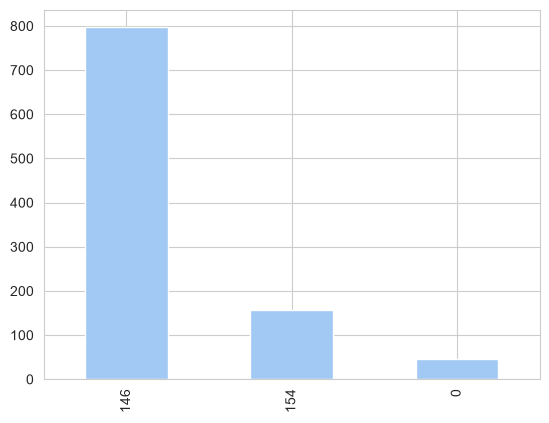

In [13]:
from collections import Counter 
ps = pd.Series(
    Counter(
        [tt.choose_reaction(filtered_table,mode="softmax",choice_temp=0.8).name for i in range(1000)]

    )
)
ps.sort_values(ascending=False).plot.bar()

run each inner loop N times 

In [14]:
conc_stats,reac_stats,scoring_stats = tt.outer_loop(
    initial_concentrations,
    path_length=20,
    inner_loop_runs=20,
    choice_temp=0.8,
    mode="softmax",
    method="sum"
)

  0%|          | 0/20 [00:00<?, ?it/s]

convergence reached.


<Axes: >

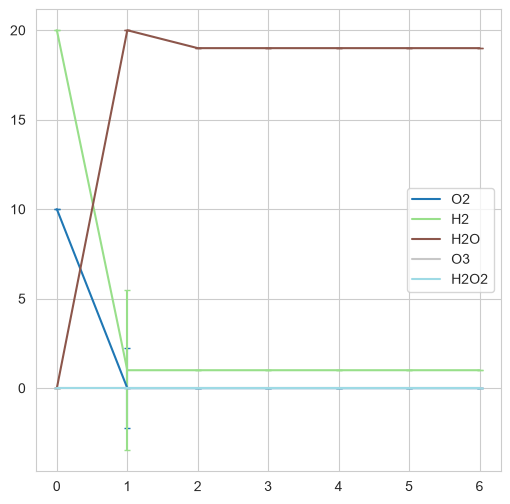

In [15]:
fig,ax = plt.subplots(figsize=(6,6),dpi=100)
dfs = [pd.DataFrame([x for x in conc_stats[i][1:] if x]) for i in conc_stats]
dfs = [df[df>0].dropna(axis=1,how="all") for df in dfs]
stds = pd.DataFrame([df.std() for df in dfs]).fillna(0)
means = pd.DataFrame([df.mean() for df in dfs]).fillna(0)

means[means>0.5].fillna(0).plot.line(ax=ax,yerr=stds,capsize=2,cmap="tab20")

In [16]:
# final concentrations  
final = means.T[len(means)-1].T.round(5)
final = pd.DataFrame([pd.Series(initial_concentrations),final],index=["initial","final"]).fillna(0).T
final[final>0.1].dropna(how="all").fillna(0)

initial     final
H2O      0.0  18.99973
O2      10.0   0.49987
H2      20.0   1.00000

#### Get the reaction statistics 

In [17]:
from collections import Counter 
stats = pd.DataFrame(
    [Counter([x for x in reac_stats[i] if not x == None]) for i in reac_stats]
).T

stats.dropna(axis=1,how="all",inplace=True)
indexes = list(stats.index)
reactions = [tt.row_to_reaction(initial_table.T[row]) for row in tqdm(initial_table.T,total=len(initial_table))]
stats["reaction"] = [reactions[index]["reaction_string"] for index in indexes]
stats.set_index("reaction",inplace=True)

  0%|          | 0/3570 [00:00<?, ?it/s]

In [18]:
stats[1].sort_values(ascending=False).dropna()

reaction
1 O2 + 2 H2 = 2 H2O    19.0
2 O3 = 3 O2             1.0
Name: 1, dtype: float64

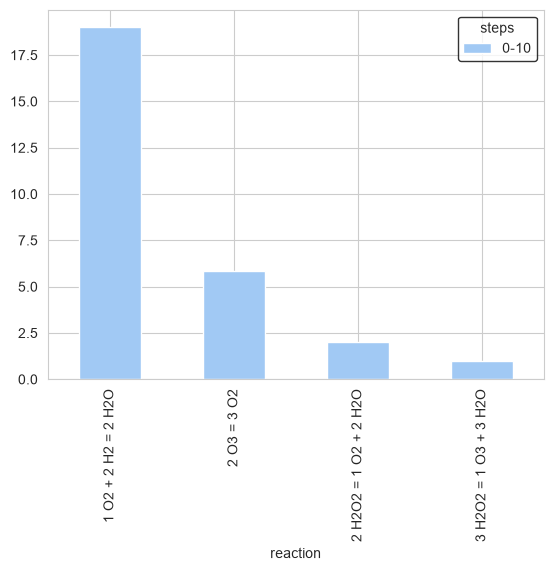

In [19]:
average_columns = 10 
groups = np.arange(stats.shape[1]) // average_columns
grouped = stats.T.groupby(groups).mean().T
grouped.columns = [f"{i*average_columns}-{i*average_columns+average_columns}" for i in range(len(grouped.T))]
ax = grouped.plot.bar(stacked=True)
ax.legend(edgecolor="black",title="steps")

In [20]:
#pd.DataFrame([scoring_stats[i].T[146] for i in range(1,50)]).reset_index().filter(["combined_score","availability_score","quotient_score","gibbs_score"]).plot.bar(stacked=True)

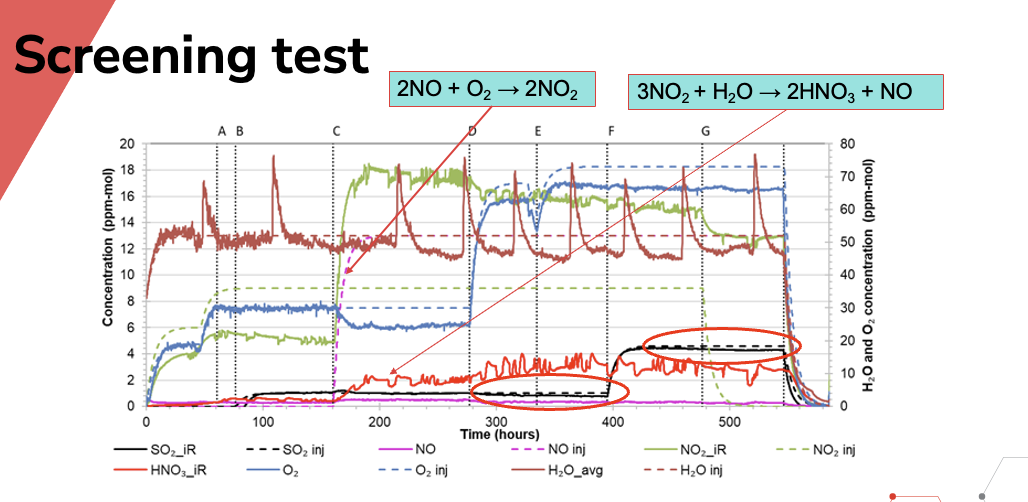

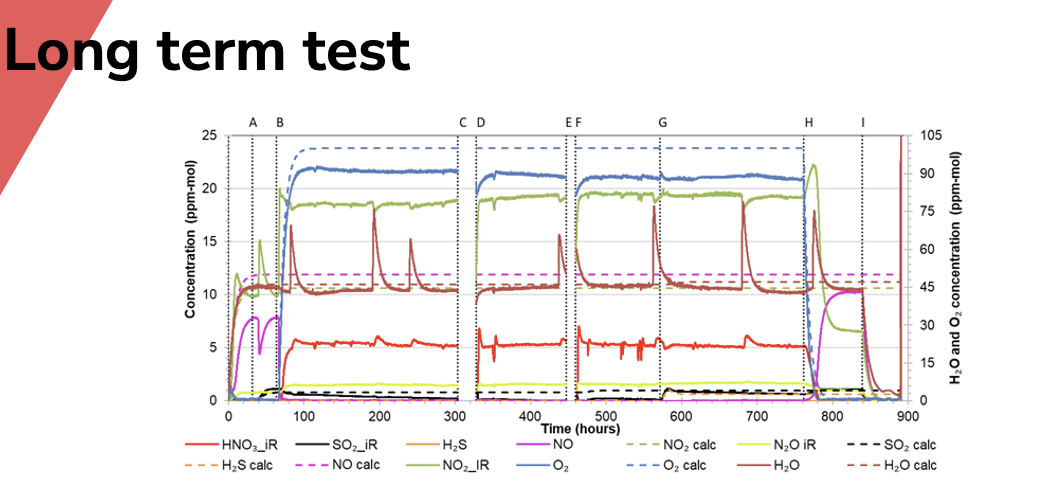

In [42]:
# first setup concentrations 
initial_concentrations = {k:0 for k in gg.compound_reference}

sven_morten_concs_screening = {
    "A":{"H2O":50,"H2S":0,"SO2":0,"NO2":9,"O2":20,"NO":0},
    "B":{"H2O":50,"H2S":0,"SO2":1,"NO2":9,"O2":30,"NO":0},
    "C":{"H2O":50,"H2S":0,"SO2":1,"NO2":9,"O2":30,"NO":13},
    "D":{"H2O":50,"H2S":0,"SO2":1,"NO2":9,"O2":73,"NO":13},
    "E":{"H2O":50,"H2S":0,"SO2":5,"NO2":9,"O2":73,"NO":13},
    "G":{"H2O":50,"H2S":0,"SO2":5,"NO2":0,"O2":73,"NO":13},
}

sven_morten_concs_long_term = {
    "A":{"H2O":50,"H2S":0,"SO2":1,"NO2":11,"O2":0,"NO":12},
    "B-F":{"H2O":50,"H2S":0,"SO2":1,"NO2":11,"O2":100,"NO":12},
    "G":{"H2O":50,"H2S":0.5,"SO2":1,"NO2":11,"O2":100,"NO":12},
    "H":{"H2O":50,"H2S":0.5,"SO2":1,"NO2":11,"O2":0,"NO":12},
}

dnv_concs ={
    "set_1":{"SO2":0,"NO2":484.7,"H2O":0,"H2S":91.8,"NO":0,"O2":0},
    #"set_1":{"SO2":74.2,"NO2":226.3,"H2O":41.9,"H2S":0,"NO":206.6,"O2":0},
    "set_2":{"SO2":9.2,"NO2":9.2,"H2O":8.6,"H2S":0,"NO":0,"O2":0}
}

original_sets = {
    "set_1": {"H2O":30,"O2":10,"SO2":10,"NO2":0,"H2S":10}
}


for k,v in sven_morten_concs_long_term["B-F"].items():
    initial_concentrations[k] = v

In [22]:
gg = GraphGenerator()
initial_table = gg.from_file(
    filename=resources.files("arcs").joinpath("data/quantum_data.json.gz"),
    temperature=278,
    pressure=40,
    max_reaction_length=4,
    graph=False
)
tt = TableTraversal(initial_table,temperature=278)

In [34]:
conc_stats,reac_stats,scoring_stats = tt.outer_loop(
    initial_concentrations,
    inner_loop_runs=20,
    path_length=50,
    choice_temp=0.8,
    convergence_how_far_back=50,
    mode="softmax",
    method="sum"
)

  0%|          | 0/50 [00:00<?, ?it/s]

<Axes: >

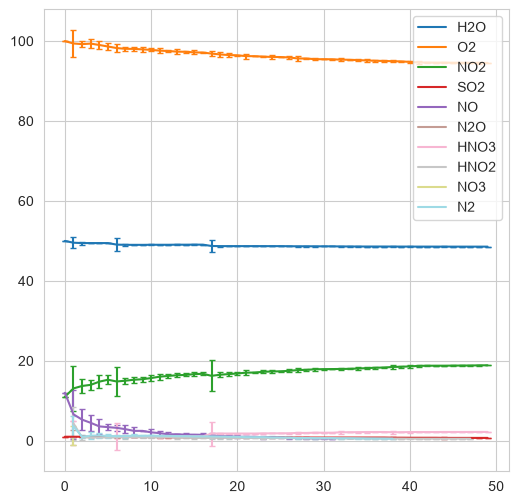

In [35]:
fig,ax = plt.subplots(figsize=(6,6),dpi=100)

dfs = [pd.DataFrame([x for x in conc_stats[i][1:] if x]) for i in conc_stats]
dfs = [df[df>0].dropna(axis=1,how="all") for df in dfs]
stds = pd.DataFrame([df.std() for df in dfs]).fillna(0)
means = pd.DataFrame([df.mean() for df in dfs]).fillna(0)

#means[means>0.5].fillna(0).plot.line(ax=ax,yerr=stds,capsize=2,cmap="tab20")
means.T[means.T>0.5].dropna(axis=0,how="all").T.plot.line(ax=ax,yerr=stds,capsize=2,cmap="tab20")

In [36]:
# final concentrations  
final = means.T[len(means)-1].T.round(5)
final = pd.DataFrame([pd.Series(initial_concentrations),final],index=["initial","final"]).fillna(0).T
final[final>0.5].dropna(how="all").fillna(0)

initial     final
H2O      50.0  48.56637
O2      100.0  94.53671
HNO3      0.0   2.20567
NO2      11.0  18.87875
SO2       1.0   0.70793
NO       12.0   0.00000

In [37]:
# reaction statistics 
from collections import Counter 
stats = pd.DataFrame(
    [Counter([x for x in reac_stats[i] if not x == None]) for i in reac_stats]
).T

stats.dropna(axis=1,how="all",inplace=True)
indexes = list(stats.index)
reactions = [tt.row_to_reaction(initial_table.T[row]) for row in tqdm(initial_table.T,total=len(initial_table))]
stats["reaction"] = [reactions[index]["reaction_string"] for index in indexes]
stats.set_index("reaction",inplace=True)

  0%|          | 0/3570 [00:00<?, ?it/s]

In [38]:
average_columns = 10 
groups = np.arange(stats.shape[1]) // average_columns
grouped = stats.T.groupby(groups).sum().T
grouped.columns = [f"{i*average_columns}-{i*average_columns+average_columns}" for i in range(len(grouped.T))]
grouped.sort_values(by="0-10",ascending=False)#ax = grouped.plot.bar(stacked=True)

#ax.legend(edgecolor="black",title="steps")

0-10  10-20  20-30  30-40  40-50
reaction                                                        
1 O2 + 2 H2 = 2 H2O             40.0   46.0   48.0   73.0   80.0
1 O2 + 2 NO = 2 NO2             15.0   11.0    8.0    5.0    4.0
1 O2 + 1 N2O2 = 2 NO2           14.0    6.0   10.0    9.0   14.0
1 N2O2 = 2 NO                    9.0    5.0    7.0    6.0    5.0
1 O3 + 3 H2 = 3 H2O              7.0    8.0    9.0    8.0   11.0
...                              ...    ...    ...    ...    ...
2 NO2 + 1 H2 = 2 HNO2            0.0    1.0    0.0    0.0    0.0
5 O2 + 2 NH3 = 2 NO2 + 3 H2O2    0.0    1.0    1.0    0.0    0.0
2 N2O2 + 1 H2 = 2 N2O + 1 H2O2   0.0    1.0    0.0    1.0    0.0
7 NO3 + 2 NH3 = 3 NO + 6 HNO3    0.0    1.0    0.0    0.0    0.0
2 SO3 + 1 H2S = 3 SO2 + 1 H2     0.0    0.0    0.0    0.0    1.0

[261 rows x 5 columns]

Text(0.5, 1.0, '28')

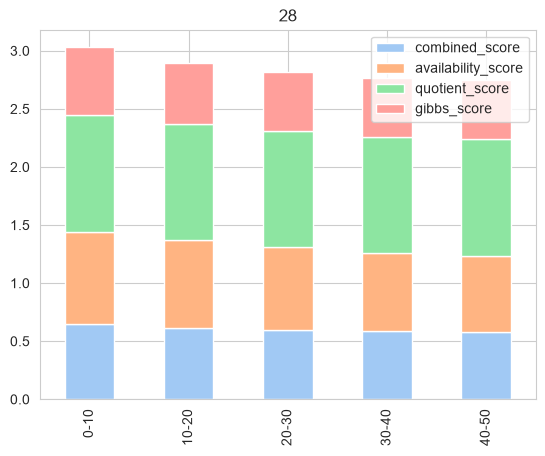

In [39]:
reaction = 28 
scoring_stats_df = pd.DataFrame(
    [scoring_stats[i].T[reaction] for i in range(1, 50)]
    ).reset_index(
).filter(
    ["combined_score", "availability_score", "quotient_score", "gibbs_score"]
    )

average_columns = 10 
groups = np.arange(scoring_stats_df.shape[0]) // average_columns
grouped_scores = scoring_stats_df.groupby(groups).mean()
grouped_scores.index = [f"{i*average_columns}-{i*average_columns+average_columns}" for i in range(len(grouped.T))]

ax = grouped_scores.plot.bar(stacked=True)
ax.set_title(reaction)
# .plot.bar(stacked=True)

### Sandbox - testing multiple runs 

In [40]:
gg = GraphGenerator()
initial_table = gg.from_file(
    filename=resources.files("arcs").joinpath("data/quantum_data.json.gz"),
    temperature=278,
    pressure=40,
    max_reaction_length=4,
    graph=False
)
tt = TableTraversal(initial_table,temperature=278)

In [ ]:
#initial_concentrations = {c:0 for c in gg.compound_reference}
#initial_concentrations["O2"] = 10
#initial_concentrations["H2"] = 20
#initial_concentrations["SO2"] = 1

In [43]:
conc_stats = []
reac_stats = []
scoring_stats = []
for i in range(10):
    cs, rs, ss = tt.outer_loop(
        initial_concentrations,
        inner_loop_runs=2,
        choice_temp=0.8,
        mode="softmax",
        method="sum"
    )

    dfs = [pd.DataFrame([x for x in cs[i][1:] if x]) for i in cs]
    dfs = [df[df>0].dropna(axis=1,how="all") for df in dfs]
    stds = pd.DataFrame([df.std() for df in dfs]).fillna(0)
    means = pd.DataFrame([df.mean() for df in dfs]).fillna(0)
    conc_stats.append(means)
    reac_stats.append(rs)
    scoring_stats.append(ss)


  0%|          | 0/50 [00:00<?, ?it/s]

convergence reached.


  0%|          | 0/50 [00:00<?, ?it/s]

convergence reached.


  0%|          | 0/50 [00:00<?, ?it/s]

...

convergence reached.


  0%|          | 0/50 [00:00<?, ?it/s]

convergence reached.


  0%|          | 0/50 [00:00<?, ?it/s]

convergence reached.


<Axes: >

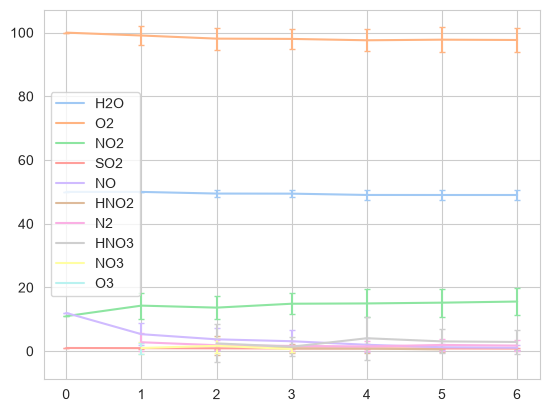

In [44]:
df_avg = pd.concat(conc_stats).groupby(level=0).mean()
df_std = pd.concat(conc_stats).groupby(level=0).std()
df_avg.T[df_avg.T>0.5].dropna(axis=0,how="all").T.plot.line(yerr=df_std,capsize=2)

In [47]:
df_avg.T[df_avg.T>0.5].dropna(axis=0,how="all")

0          1          2          3          4          5          6
H2O    50.0  49.999535  49.480163  49.452628  49.040121  49.029783  49.030015
O2    100.0  99.098832  98.116670  98.029162  97.600876  97.791088  97.691824
NO2    11.0  14.297991  13.671375  14.896073  14.986101  15.229737  15.579771
SO2     1.0   0.950000   0.900000   0.850000   0.850000   0.849996   0.809764
NO     12.0   5.330583   3.717576   3.120246   2.011412   1.233576   1.082873
HNO2    NaN        NaN   1.709887   0.854943   0.821610   0.544355        NaN
N2      NaN   2.799406   1.872191   1.647030   1.494254   1.954932   1.754478
HNO3    NaN        NaN   2.440867   1.404004   4.058099   3.074036   2.881163
NO3     NaN   0.999920   1.687611   0.656290        NaN        NaN        NaN
O3      NaN   0.761846        NaN        NaN        NaN        NaN        NaN

In [ ]:
reac_stats[0]